# BITCOIN DATASET


**Phase 1: Data Exploration and Preparation**

1.1. Data Exploration
*   Identify relevant features for predicting Bitcoin prices.
*   Visualize the price data over time series to identify trends, seasonality, and potential outliers.
*   Calculate descriptive statistics for numerical features (mean, median, standard deviation) and analyze categorical features (frequency distribution).
*   Check for missing values and implement appropriate strategies (e.g., imputation, removal) to handle them.

In [ ]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
df_bitcoin=pd.read_csv('/content/Bitcoin.csv')
df_bitcoin

,Date,Open,High,Low,Close,Volume,Currency
0,2019-06-18,9128.269531,9149.763672,8988.606445,9062.045898,952850.0,USD
1,2019-06-19,9068.174805,9277.677734,9051.094727,9271.459961,131077.0,USD
2,2019-06-20,9271.567383,9573.689453,9209.416992,9519.200195,83052.0,USD
3,2019-06-21,9526.833984,10130.935547,9526.833984,10127.998047,76227.0,USD
4,2019-06-22,10151.890625,11171.013672,10083.189453,10719.981445,84485.0,USD
...,...,...,...,...,...,...,...
1146,2022-08-18,23331.542969,23567.285156,23152.455078,23222.242188,4546110.0,USD
1147,2022-08-19,23219.097656,23219.097656,20898.304688,20902.404297,13856579.0,USD
1148,2022-08-20,20899.923828,21344.845703,20864.435547,21153.019531,7139073.0,USD
1149,2022-08-21,21153.412109,21695.794922,21125.320312,21561.177734,6657571.0,USD


In [ ]:
#Check # of unique value in each column
df_bitcoin['Currency'].nunique()

1

In [ ]:
#Drop the Currency column
df1_bitcoin=df_bitcoin.drop(['Currency'],axis=1)
df1_bitcoin

,Date,Open,High,Low,Close,Volume
0,2019-06-18,9128.269531,9149.763672,8988.606445,9062.045898,952850.0
1,2019-06-19,9068.174805,9277.677734,9051.094727,9271.459961,131077.0
2,2019-06-20,9271.567383,9573.689453,9209.416992,9519.200195,83052.0
3,2019-06-21,9526.833984,10130.935547,9526.833984,10127.998047,76227.0
4,2019-06-22,10151.890625,11171.013672,10083.189453,10719.981445,84485.0
...,...,...,...,...,...,...
1146,2022-08-18,23331.542969,23567.285156,23152.455078,23222.242188,4546110.0
1147,2022-08-19,23219.097656,23219.097656,20898.304688,20902.404297,13856579.0
1148,2022-08-20,20899.923828,21344.845703,20864.435547,21153.019531,7139073.0
1149,2022-08-21,21153.412109,21695.794922,21125.320312,21561.177734,6657571.0


In [ ]:
print(df1_bitcoin.info())
print(df1_bitcoin.describe().round(1))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1151 entries, 0 to 1150
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1151 non-null   object 
 1   Open    1151 non-null   float64
 2   High    1151 non-null   float64
 3   Low     1151 non-null   float64
 4   Close   1151 non-null   float64
 5   Volume  1151 non-null   float64
dtypes: float64(5), object(1)
memory usage: 54.1+ KB
None
          Open     High      Low    Close       Volume
count   1151.0   1151.0   1151.0   1151.0       1151.0
mean   26488.7  27528.4  25416.6  26496.7   28740512.7
std    17963.1  18432.9  17484.6  17952.1   52029986.2
min     4943.8   5338.5      0.1   4936.8          0.0
25%     9706.8  10090.0   9360.6   9712.6       7495.5
50%    20873.3  21867.8  20245.2  20902.4    1864334.0
75%    41782.3  42749.4  40890.4  41782.3   40764712.0
max    67470.4  85564.0  66072.3  67502.4  579170589.0


the min volume of 0 --> might be no transactions on some days

In [ ]:
#Show the data with 0 values
df1_bitcoin[df1_bitcoin['Volume']==0]

,Date,Open,High,Low,Close,Volume
551,2020-12-20,20032.421875,24315.615234,19427.007812,23410.105469,0.0
552,2020-12-21,23408.089844,24261.000000,21757.462891,22036.162109,0.0
555,2020-12-24,22942.250000,23980.751953,20083.648438,20245.173828,0.0


<Axes: >

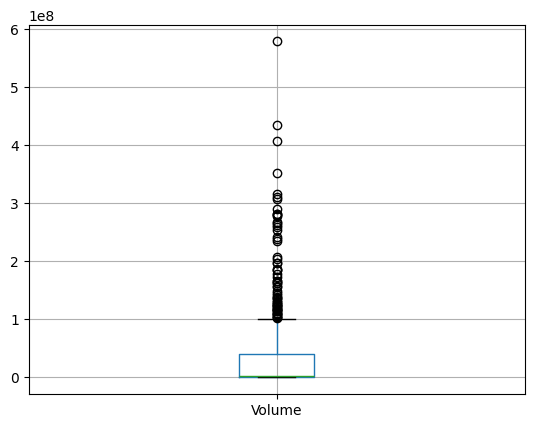

In [ ]:
#Plot boxplot to see the distribution of the dataset
df1_bitcoin.boxplot(column=['Volume'])

<Axes: >

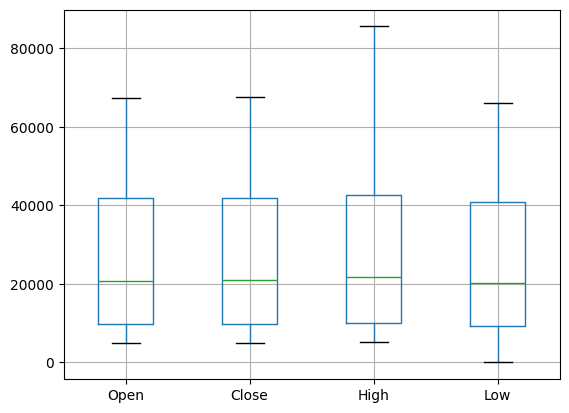

In [ ]:
df1_bitcoin.boxplot(column=['Open','Close','High','Low'])

In [ ]:
#Convert the 'Date' column to date format
df1_bitcoin['Date'] = pd.to_datetime(df1_bitcoin['Date'])
df1_bitcoin.sort_values(by='Date', inplace=True)

#Use "Date" as index column
df1_bitcoin.set_index('Date',inplace=True)
df1_bitcoin

,Open,High,Low,Close,Volume
Date,,,,,
2019-06-18,9128.269531,9149.763672,8988.606445,9062.045898,952850.0
2019-06-19,9068.174805,9277.677734,9051.094727,9271.459961,131077.0
2019-06-20,9271.567383,9573.689453,9209.416992,9519.200195,83052.0
2019-06-21,9526.833984,10130.935547,9526.833984,10127.998047,76227.0
2019-06-22,10151.890625,11171.013672,10083.189453,10719.981445,84485.0
...,...,...,...,...,...
2022-08-18,23331.542969,23567.285156,23152.455078,23222.242188,4546110.0
2022-08-19,23219.097656,23219.097656,20898.304688,20902.404297,13856579.0
2022-08-20,20899.923828,21344.845703,20864.435547,21153.019531,7139073.0


In [ ]:
#Check the missing dates in data
full_date_range = pd.date_range(start=df1_bitcoin.index.min(), end=df1_bitcoin.index.max(), freq='D')
missing_dates = full_date_range.difference(df1_bitcoin.index)
print(missing_dates)

DatetimeIndex(['2021-12-21', '2021-12-22', '2021-12-23', '2021-12-24',
               '2021-12-25', '2021-12-26', '2021-12-27', '2021-12-28',
               '2021-12-29', '2021-12-30', '2021-12-31', '2022-08-22'],
              dtype='datetime64[ns]', freq=None)


In [ ]:
# Resample to daily frequency, fill in NaN for missing dates
df2_bitcoin = df1_bitcoin.asfreq('D')
df2_bitcoin

,Open,High,Low,Close,Volume
Date,,,,,
2019-06-18,9128.269531,9149.763672,8988.606445,9062.045898,952850.0
2019-06-19,9068.174805,9277.677734,9051.094727,9271.459961,131077.0
2019-06-20,9271.567383,9573.689453,9209.416992,9519.200195,83052.0
2019-06-21,9526.833984,10130.935547,9526.833984,10127.998047,76227.0
2019-06-22,10151.890625,11171.013672,10083.189453,10719.981445,84485.0
...,...,...,...,...,...
2022-08-19,23219.097656,23219.097656,20898.304688,20902.404297,13856579.0
2022-08-20,20899.923828,21344.845703,20864.435547,21153.019531,7139073.0
2022-08-21,21153.412109,21695.794922,21125.320312,21561.177734,6657571.0


In [ ]:
# Calculate the median values for each column
median_bit = df2_bitcoin.median()

# Fill missing values (NaN) with the corresponding median values
df2_bitcoin = df2_bitcoin.fillna(median_bit)

print(df2_bitcoin)

                    Open          High           Low         Close      Volume
Date                                                                          
2019-06-18   9128.269531   9149.763672   8988.606445   9062.045898    952850.0
2019-06-19   9068.174805   9277.677734   9051.094727   9271.459961    131077.0
2019-06-20   9271.567383   9573.689453   9209.416992   9519.200195     83052.0
2019-06-21   9526.833984  10130.935547   9526.833984  10127.998047     76227.0
2019-06-22  10151.890625  11171.013672  10083.189453  10719.981445     84485.0
...                  ...           ...           ...           ...         ...
2022-08-19  23219.097656  23219.097656  20898.304688  20902.404297  13856579.0
2022-08-20  20899.923828  21344.845703  20864.435547  21153.019531   7139073.0
2022-08-21  21153.412109  21695.794922  21125.320312  21561.177734   6657571.0
2022-08-22  20873.337891  21867.822266  20245.201172  20902.404297   1864334.0
2022-08-23  21337.318359  21412.892578  21280.458984

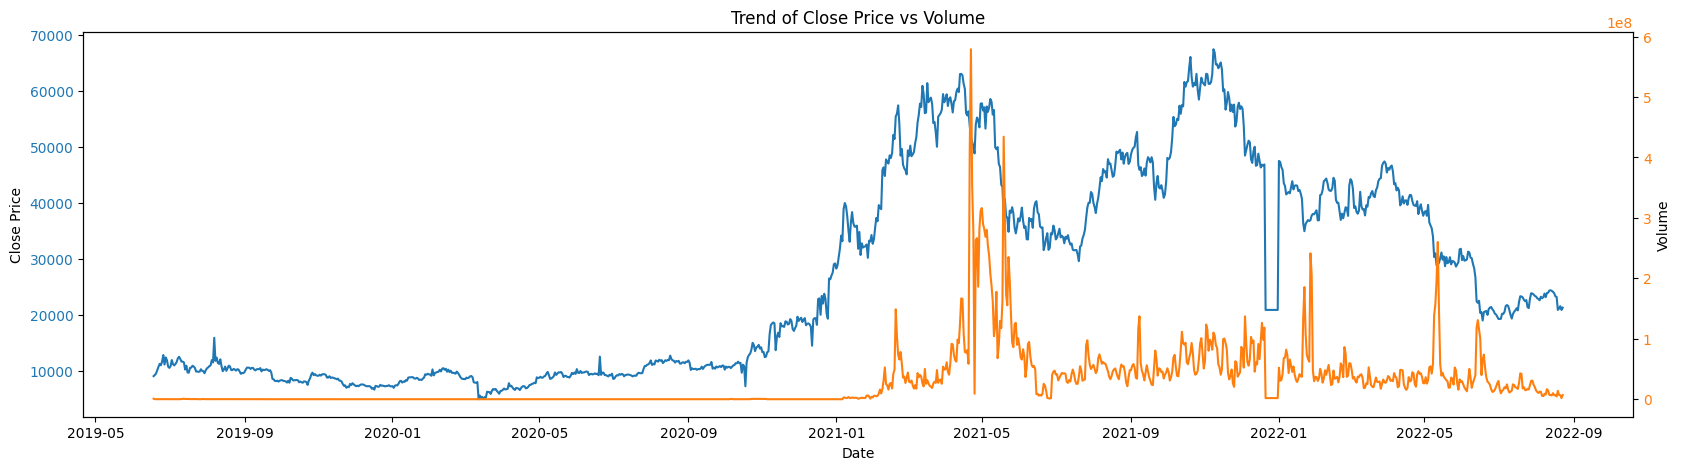

In [ ]:
#Plot the trend of close price vs volume
fig_clo_vol,ax1=plt.subplots(figsize=(20,5))
ax1.plot(df2_bitcoin.index,df2_bitcoin['Close'],color='C0')
ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price')
ax1.tick_params(axis='y', labelcolor='C0')

ax2=ax1.twinx()
ax2.plot(df2_bitcoin.index,df2_bitcoin['Volume'],color='C1')
ax2.set_ylabel('Volume')
ax2.tick_params(axis='y', labelcolor='C1')

ax1.set_title('Trend of Close Price vs Volume')

plt.show()

In [ ]:
# Create another df by resampling df1 to daily frequency, fill in NaN for missing dates
df3_bitcoin = df1_bitcoin.asfreq('D')

# Calculate the median values for each column (equal to the median of data 2021-2022)
data_range = df3_bitcoin.loc['2021-01-01':'2022-08-23'] # Select the data for the specified period
median_bit2 = data_range.median()

# Fill missing values (NaN) with the corresponding median values
df3_bitcoin = df3_bitcoin.fillna(median_bit2)

print(df3_bitcoin)

                    Open          High           Low         Close      Volume
Date                                                                          
2019-06-18   9128.269531   9149.763672   8988.606445   9062.045898    952850.0
2019-06-19   9068.174805   9277.677734   9051.094727   9271.459961    131077.0
2019-06-20   9271.567383   9573.689453   9209.416992   9519.200195     83052.0
2019-06-21   9526.833984  10130.935547   9526.833984  10127.998047     76227.0
2019-06-22  10151.890625  11171.013672  10083.189453  10719.981445     84485.0
...                  ...           ...           ...           ...         ...
2022-08-19  23219.097656  23219.097656  20898.304688  20902.404297  13856579.0
2022-08-20  20899.923828  21344.845703  20864.435547  21153.019531   7139073.0
2022-08-21  21153.412109  21695.794922  21125.320312  21561.177734   6657571.0
2022-08-22  41531.224609  42462.388672  40616.787109  41531.224609  40490951.0
2022-08-23  21337.318359  21412.892578  21280.458984

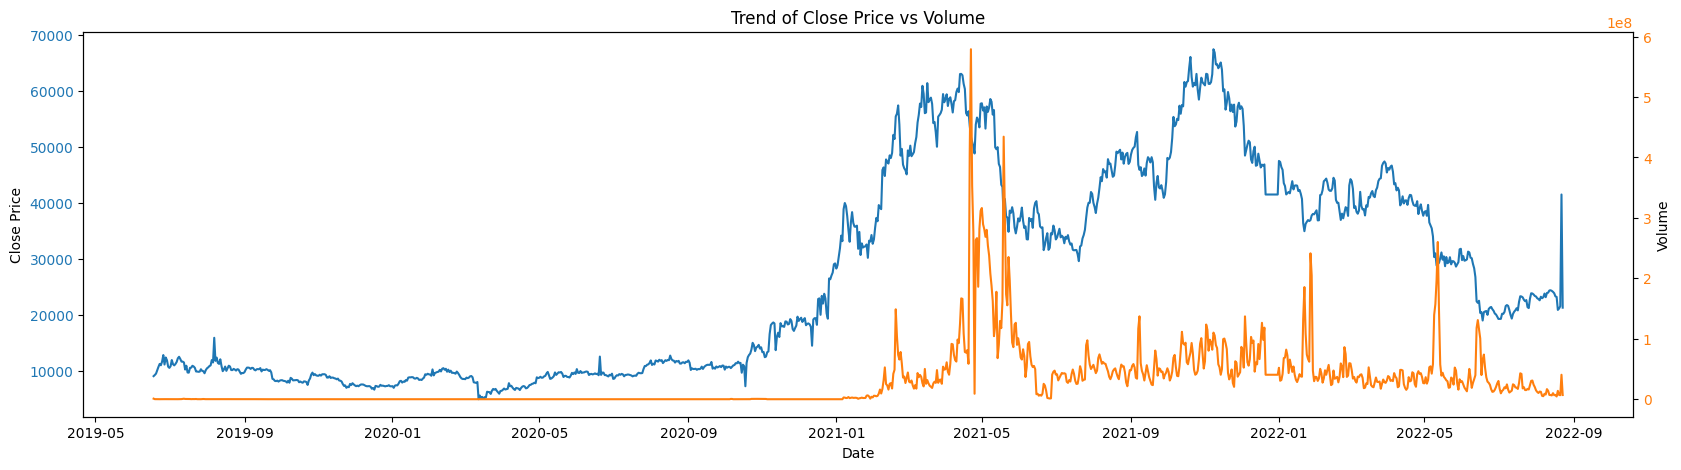

In [ ]:
#Plot the trend of close price vs volume
fig_clo_vol1,ax1=plt.subplots(figsize=(20,5))
ax1.plot(df3_bitcoin.index,df3_bitcoin['Close'],color='C0')
ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price')
ax1.tick_params(axis='y', labelcolor='C0')

ax2=ax1.twinx()
ax2.plot(df3_bitcoin.index,df3_bitcoin['Volume'],color='C1')
ax2.set_ylabel('Volume')
ax2.tick_params(axis='y', labelcolor='C1')

ax1.set_title('Trend of Close Price vs Volume')

plt.show()

from 2019 - end of 2020, the volume of bitcoin sold and the close price is considerably low. the volume increase significantly started from the beginning of 2021 and then reached the peak at the end of April 2021.
the volume purchased is high when bitcoin dropped in close price.

In [ ]:
#Plot the trend of Open vs Close
fig_bit_opcl=px.line(df3_bitcoin,x=df3_bitcoin.index,y=['Open','Close'],title='Trend of Open vs Close')
fig_bit_opcl.show()

In [ ]:
#Plot the trend of High vs Low
fig_bit_hilo=px.line(df3_bitcoin,x=df3_bitcoin.index,y=['High','Low'],title='Trend of High vs Low')
fig_bit_hilo.show()

1.2 Data Preprocessing (LO2):
*   Define the target variable as the future Bitcoin and Ethereum prices (e.g., closing price in the next time window).
*   Select relevant features based on the exploration phase. Consider feature engineering techniques to create new features from existing ones (e.g., price change, price spread).
*   Scale the features to a common range (e.g., standardization, normalization) to improve model performance

In [ ]:
# Feature engineering
df3_bitcoin['Price_Change'] = df3_bitcoin['Close'] - df3_bitcoin['Open']
df3_bitcoin['Price_Spread'] = df3_bitcoin['High'] - df3_bitcoin['Low']
df3_bitcoin['Daily_Return'] = df3_bitcoin['Close'].pct_change()
df3_bitcoin['MA_7'] = df3_bitcoin['Close'].rolling(window=7).mean()
df3_bitcoin['MA_30'] = df3_bitcoin['Close'].rolling(window=30).mean()

# Shift the 'Close' column by 1 to get the target closing price of the next day
df3_bitcoin['Target_Close'] = df3_bitcoin['Close'].shift(-1)
df3_bitcoin.dropna(inplace=True)

df3_bitcoin

,Open,High,Low,Close,Volume,Price_Change,Price_Spread,Daily_Return,MA_7,MA_30,Target_Close
Date,,,,,,,,,,,
2019-07-17,9833.953125,10002.206055,9138.093750,9685.883789,444337.0,-148.069336,864.112305,-0.003206,10771.386858,11076.655436,10548.814453
2019-07-18,9689.371094,10660.923828,9239.602539,10548.814453,321096.0,859.443359,1421.321289,0.089092,10612.605469,11126.214388,10572.655273
2019-07-19,10548.814453,10825.875000,10193.408203,10572.655273,122121.0,23.840820,632.466797,0.002260,10458.347656,11169.587565,10913.607422
2019-07-20,10597.679688,11314.213867,10265.417969,10913.607422,240565.0,315.927734,1048.795898,0.032248,10372.339565,11216.067806,10792.991211
2019-07-21,10913.607422,11229.353516,10204.167969,10792.991211,145889.0,-120.616211,1025.185547,-0.011052,10451.065011,11238.234245,10556.007812
...,...,...,...,...,...,...,...,...,...,...,...
2022-08-18,23331.542969,23567.285156,23152.455078,23222.242188,4546110.0,-109.300781,414.830078,-0.004485,23950.169922,23276.922786,20902.404297
2022-08-19,23219.097656,23219.097656,20898.304688,20902.404297,13856579.0,-2316.693359,2320.792969,-0.099897,23453.934152,23197.003190,21153.019531
2022-08-20,20899.923828,21344.845703,20864.435547,21153.019531,7139073.0,253.095703,480.410156,0.011990,22988.511161,23130.554167,21561.177734


In [ ]:
#Split the time-series data into train and test
df1_train = df3_bitcoin.loc[:'2021-12-31']
df1_test = df3_bitcoin.loc['2022-01-01':]

#Define features X and target Y
X_train_1 = df1_train.drop(['Target_Close'], axis=1)
y_train = df1_train['Target_Close']
X_test_1 = df1_test.drop(['Target_Close'], axis=1)
y_test = df1_test['Target_Close']

# Scale the features using StandardScaler (less affected by outliers)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_1_scaled = scaler.fit_transform(X_train_1) # Fit the scaler on the training data only
X_test_1_scaled = scaler.transform(X_test_1) # Use the same scaler to transform the test data

print('X_train_scaled\n',X_train_1_scaled)
print('\nX_test_scaled\n',X_test_1_scaled)

X_train_scaled
 [[-0.80192287 -0.82844014 -0.80194172 ... -0.11114565 -0.75203026
  -0.72325717]
 [-0.80941704 -0.79528761 -0.79652061 ...  1.47260263 -0.76028346
  -0.72064815]
 [-0.76486922 -0.7869858  -0.74558231 ... -0.01735046 -0.76830154
  -0.71836479]
 ...
 [ 0.84105259  0.80524459  0.87918829 ... -0.05613089  0.84681717
   1.18531735]
 [ 0.84105259  0.80524459  0.87918829 ... -0.05613089  0.84681717
   1.15850397]
 [ 0.84105259  0.80524459  0.87918829 ... -0.05613089  0.84681717
   1.13083994]]

X_test_scaled
 [[ 1.09034899e+00  1.07215409e+00  1.18469025e+00 ...  2.42341181e+00
   8.91380345e-01  1.11450325e+00]
 [ 1.15212421e+00  1.07593112e+00  1.21346822e+00 ... -1.20042864e-01
   9.34628890e-01  1.10321411e+00]
 [ 1.14294748e+00  1.05556837e+00  1.16641416e+00 ... -3.90815974e-01
   9.71018809e-01  1.09960086e+00]
 ...
 [-2.28336646e-01 -2.57577756e-01 -1.75692565e-01 ...  1.49603245e-01
  -1.17003575e-01 -8.86838997e-02]
 [-2.15197501e-01 -2.39914874e-01 -1.61759928e-01 .

**Phase 2: Feature Selection (LO2):**

<Axes: >

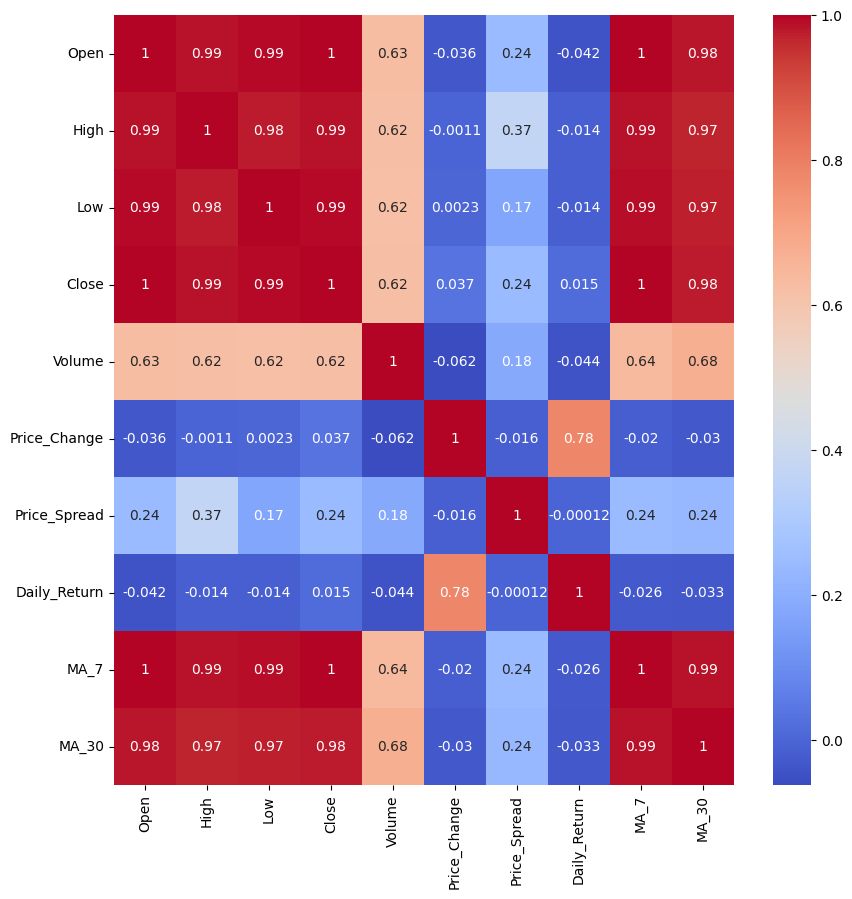

In [ ]:
#Create correlation matrix
corr_matrix= pd.DataFrame(X_train_1_scaled,columns=X_train_1.columns).corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')

In [ ]:
#Drop Close, High, Low, MA_7, MA_30 out of X_train_1 and X_test_1
X_train_2 = X_train_1.drop(['Close','High','Low','MA_7','MA_30'], axis=1)
X_test_2 = X_test_1.drop(['Close','High','Low','MA_7','MA_30'], axis=1)

# Scale the features using StandardScaler
X_train_2_scaled = scaler.fit_transform(X_train_2)
X_test_2_scaled = scaler.transform(X_test_2)

print('X_train_scaled\n',X_train_2_scaled)
print('\nX_test_scaled\n',X_test_2_scaled)

X_train_scaled
 [[-0.80192287 -0.47876978 -0.13229974 -0.34584457 -0.11114565]
 [-0.80941704 -0.48099595  0.58610408 -0.21242695  1.47260263]
 [-0.76486922 -0.48459014 -0.00971973 -0.40130956 -0.01735046]
 ...
 [ 0.84105259  0.24461272 -0.02671935 -0.11083766 -0.05613089]
 [ 0.84105259  0.24461272 -0.02671935 -0.11083766 -0.05613089]
 [ 0.84105259  0.24461272 -0.02671935 -0.11083766 -0.05613089]]

X_test_scaled
 [[ 1.09034899  0.45289125  0.8230933  -0.21071556  2.42341181]
 [ 1.15212421  0.06523294 -0.1529593  -0.32177042 -0.12004286]
 [ 1.14294748  0.08683077 -0.68533238 -0.20768236 -0.39081597]
 ...
 [-0.22833665 -0.35783934  0.15374976 -0.43771787  0.14960325]
 [-0.2151975  -0.36653696  0.26403667 -0.41615292  0.2749631 ]
 [ 0.84105259  0.24461272 -0.02671935 -0.11083766 15.8367177 ]]


Phase 3: Model Training and Evaluation (LO2, LO3)

3.1 Model Selection and Training (LO2, LO3):
*  Implement Random Forest, Regression, and KNN models for Bitcoin price prediction.
*  Split the data into training and testing sets.
*  Train each model on the training set.
3.2 Model Evaluation (LO2):
*  Evaluate the performance of each model on the testing set using Root Mean Squared Error (RMSE).
*  RMSE measures the average difference between predicted and actual prices.
*  Compare the RMSE of different models and select the one with the lowest error for optimal price prediction

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error
# Initialize the models
models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'Linear Regression': LinearRegression(),
    'KNN': KNeighborsRegressor()
}

# Train and evaluate the models with the train_test set before feature selection
for model_name, model in models.items():
    model.fit(X_train_1_scaled, y_train)
    y_pred_1 = model.predict(X_test_1_scaled)
    rmse_1 = root_mean_squared_error(y_test, y_pred_1)
    print(f'{model_name} RMSE: {rmse_1:.2f}')

Random Forest RMSE: 3554.70
Linear Regression RMSE: 2121.76
KNN RMSE: 3431.30


In [ ]:
# Train and evaluate the models with the train_test set after feature selection
for model_name, model in models.items():
    model.fit(X_train_2_scaled, y_train)
    y_pred_2 = model.predict(X_test_2_scaled)
    rmse_2 = root_mean_squared_error(y_test, y_pred_2)
    print(f'{model_name} RMSE: {rmse_2:.2f}')

Random Forest RMSE: 3056.83
Linear Regression RMSE: 2118.41
KNN RMSE: 5362.65


From the data we can see that in the first 2 years, the price and volume are really low compared to the last 2 years --> corona time, the financial problems are common around the world, however, this situation improved starting from 2021. This is one example of the possible insights. Since the market is sensitive and link directly to the situation of that time. It might make more sense to use more current data to predict the price. Therefore, the author will try to predict the price with only samples from 2021 and use the last 3 months of the data as a test

In [ ]:
#Create train and test set with specified period
df3_train = df3_bitcoin.loc['2021-01-01':'2022-05-31']
df3_test = df3_bitcoin.loc['2022-06-01':'2022-08-22']

#Define features X and target Y
X_train_3 = df3_train.drop(['Target_Close','Close','High','Low','MA_7','MA_30'], axis=1)
y_train_3 = df3_train['Target_Close']
X_test_3 = df3_test.drop(['Target_Close','Close','High','Low','MA_7','MA_30'], axis=1)
y_test_3 = df3_test['Target_Close']

#Scale the features using StandardScaler
X_train_3_scaled = scaler.fit_transform(X_train_3)
X_test_3_scaled = scaler.transform(X_test_3)

In [ ]:
# Train and evaluate the models
for model_name, model in models.items():
    model.fit(X_train_3_scaled, y_train_3)
    y_pred_3 = model.predict(X_test_3_scaled)
    rmse_3 = root_mean_squared_error(y_test_3, y_pred_3)
    print(f'{model_name} RMSE: {rmse_3:.2f}')

Random Forest RMSE: 8323.90
Linear Regression RMSE: 2869.39
KNN RMSE: 8219.12


---> The model performed much worse with smaller data samples. From this, we know that the model might capture the trend better with more data.

#Ethereum dataset

Phase 1: Data Exploration and Preparation

In [ ]:
#Load the data
df_ethe=pd.read_csv('/content/ethereum.csv')
df_ethe

,date,Open,High,Low,Close,price,Currency
0,3/10/2016,11.20,11.85,11.07,11.75,4,USD
1,3/11/2016,11.75,11.95,11.75,11.95,179,USD
2,3/12/2016,11.95,13.45,11.95,12.92,833,USD
3,3/13/2016,12.92,15.07,12.92,15.07,1295,USD
4,3/14/2016,15.07,15.07,11.40,12.50,92183,USD
...,...,...,...,...,...,...,...
2353,8/19/2022,1846.52,1846.97,1607.60,1609.48,1594321,USD
2354,8/20/2022,1609.01,1654.84,1525.51,1575.60,1007240,USD
2355,8/21/2022,1575.61,1644.88,1563.92,1618.25,852071,USD
2356,8/22/2022,1618.21,1627.13,1531.91,1626.75,1044290,USD


In [ ]:
#Show the basic info of the dataset
print(df_ethe.info())
print(df_ethe.describe().applymap(lambda x: "{:.2f}".format(x)))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2358 entries, 0 to 2357
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      2358 non-null   object 
 1   Open      2358 non-null   float64
 2   High      2358 non-null   float64
 3   Low       2358 non-null   float64
 4   Close     2358 non-null   float64
 5   price     2358 non-null   int64  
 6   Currency  2358 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 129.1+ KB
None
          Open     High      Low    Close          price
count  2358.00  2358.00  2358.00  2358.00        2358.00
mean    847.61   877.39   813.52   848.27    12694668.93
std    1150.30  1186.54  1107.87  1150.26   101401267.06
min       6.68     7.32     5.86     6.70           0.00
25%     138.77   144.42   134.78   138.99      546553.00
50%     279.16   288.00   266.88   280.12     1429778.50
75%    1124.01  1170.88  1045.82  1127.73     7717626.75
max    4808.34  48

<ipython-input-44-b3cbfce74785>:3: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



In [ ]:
#Rename columns
df1_ethe = df_ethe.rename(columns={'date': 'Date', 'price': 'Volume'})

In [ ]:
#Check # of unique value
df1_ethe['Currency'].nunique()

1

In [ ]:
#Drop "Currency"
df1_ethe=df1_ethe.drop(['Currency'],axis=1)
df1_ethe.head()

,Date,Open,High,Low,Close,Volume
0,3/10/2016,11.20,11.85,11.07,11.75,4
1,3/11/2016,11.75,11.95,11.75,11.95,179
2,3/12/2016,11.95,13.45,11.95,12.92,833
3,3/13/2016,12.92,15.07,12.92,15.07,1295
4,3/14/2016,15.07,15.07,11.40,12.50,92183


In [ ]:
#Convert the 'Date' column to date format
df1_ethe['Date'] = pd.to_datetime(df1_ethe['Date'])
df1_ethe.sort_values(by='Date', inplace=True)

#Use "Date" as index column
df1_ethe.set_index('Date',inplace=True)

#Check the missing dates in data
full_date_range_1 = pd.date_range(start=df1_ethe.index.min(), end=df1_ethe.index.max(), freq='D')
missing_dates_1 = full_date_range_1.difference(df1_ethe.index)
print(missing_dates_1)

DatetimeIndex([], dtype='datetime64[ns]', freq='D')


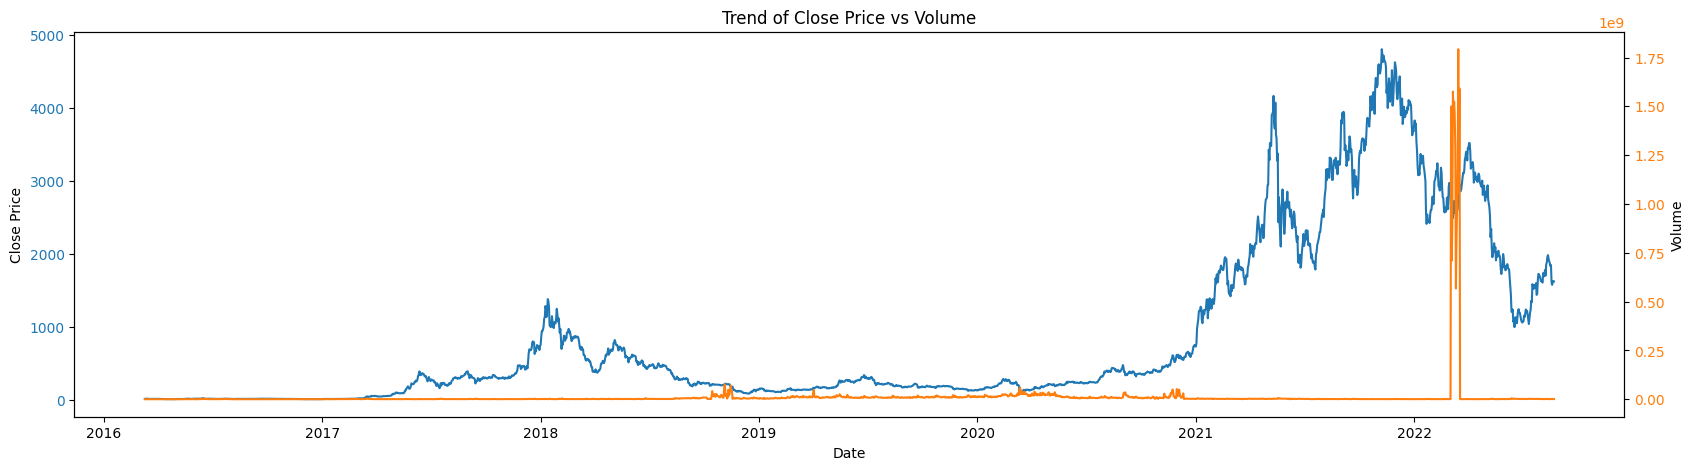

In [ ]:
#Plot the trend of close price vs volume
fig_cv_ethe,ax1=plt.subplots(figsize=(20,5))
ax1.plot(df1_ethe.index,df1_ethe['Close'],color='C0')
ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price')
ax1.tick_params(axis='y', labelcolor='C0')

ax2=ax1.twinx()
ax2.plot(df1_ethe.index,df1_ethe['Volume'],color='C1')
ax2.set_ylabel('Volume')
ax2.tick_params(axis='y', labelcolor='C1')

ax1.set_title('Trend of Close Price vs Volume')

plt.show()

In [ ]:
#plot the trend of open vs close
fig_ethe_vol=px.line(df1_ethe,x=df1_ethe.index,y='Volume',title='Trend of Volume')
fig_ethe_vol.show()

In [ ]:
#plot the trend of open vs close
fig_ethe_opcl=px.line(df1_ethe,x=df1_ethe.index,y=['Open','Close'],title='Trend of Open vs Close')
fig_ethe_opcl.show()

In [ ]:
#plot the trend of high vs low
fig_ethe_hilo=px.line(df1_ethe,x=df1_ethe.index,y=['High','Low'],title='Trend of High vs Low')
fig_ethe_hilo.show()

<Axes: >

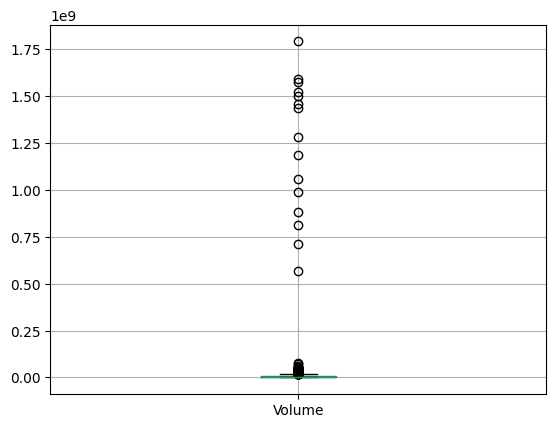

In [ ]:
#Plot box plot
df1_ethe.boxplot(column=['Volume'])

<Axes: >

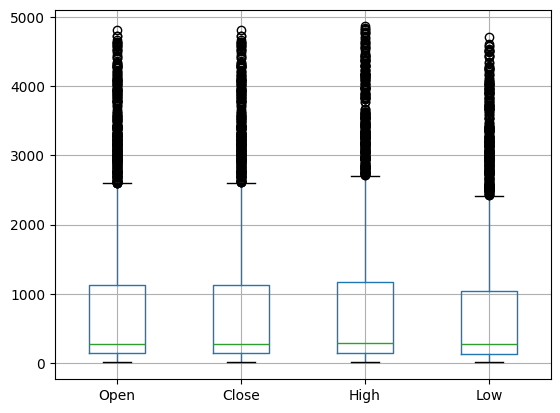

In [ ]:
df1_ethe.boxplot(column=['Open','Close','High','Low'])

1.2 Data Preprocessing (LO2):
*   Define the target variable as the future Bitcoin and Ethereum prices (e.g., closing price in the next time window).
*   Select relevant features based on the exploration phase. Consider feature engineering techniques to create new features from existing ones (e.g., price change, price spread).
*   Scale the features to a common range (e.g., standardization, normalization) to improve model performance

In [ ]:
# Feature engineering
df1_ethe['Price_Change'] = df1_ethe['Close'] - df1_ethe['Open']
df1_ethe['Price_Spread'] = df1_ethe['High'] - df1_ethe['Low']
df1_ethe['Daily_Return'] = df1_ethe['Close'].pct_change()
df1_ethe['MA_7'] = df1_ethe['Close'].rolling(window=7).mean()
df1_ethe['MA_30'] = df1_ethe['Close'].rolling(window=30).mean()

# Shift the 'Close' column by 1 to get the target closing price of the next day
df1_ethe['Target_Close'] = df1_ethe['Close'].shift(-1)
df1_ethe.dropna(inplace=True)

df1_ethe

,Open,High,Low,Close,Volume,Price_Change,Price_Spread,Daily_Return,MA_7,MA_30,Target_Close
Date,,,,,,,,,,,
2016-04-08,10.05,10.34,9.60,9.71,25974,-0.34,0.74,-0.040514,10.785714,11.497000,9.15
2016-04-09,9.69,10.20,9.00,9.15,64964,-0.54,1.20,-0.057673,10.434286,11.410333,8.76
2016-04-10,9.15,9.43,7.52,8.76,171987,-0.39,1.91,-0.042623,10.007143,11.304000,8.68
2016-04-11,8.56,8.93,8.01,8.68,60277,0.12,0.92,-0.009132,9.654286,11.162667,7.53
2016-04-12,8.53,8.54,7.21,7.53,63823,-1.00,1.33,-0.132488,9.244286,10.911333,8.09
...,...,...,...,...,...,...,...,...,...,...,...
2022-08-18,1834.19,1880.22,1822.04,1846.51,675269,12.32,58.18,0.006722,1904.838571,1709.688333,1609.48
2022-08-19,1846.52,1846.97,1607.60,1609.48,1594321,-237.04,239.37,-0.128366,1855.102857,1712.649667,1575.60
2022-08-20,1609.01,1654.84,1525.51,1575.60,1007240,-33.41,129.33,-0.021050,1796.831429,1712.647000,1618.25


In [ ]:
#Split the time-series data into train and test
df_ethe_train = df1_ethe.loc[:'2021-12-31']
df_ethe_test = df1_ethe.loc['2022-01-01':]

#Define features X and target Y
X_train_et = df_ethe_train.drop(['Target_Close'], axis=1)
y_train_et = df_ethe_train['Target_Close']
X_test_et = df_ethe_test.drop(['Target_Close'], axis=1)
y_test_et = df_ethe_test['Target_Close']

# Scale the features using StandardScaler
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
X_train_et_scaled = scaler.fit_transform(X_train_et)
X_test_et_scaled = scaler.transform(X_test_et)

print('X_train_scaled\n',X_train_et_scaled)
print('\nX_test_scaled\n',X_test_et_scaled)

X_train_scaled
 [[-0.63837007 -0.64059519 -0.63634375 ... -0.794915   -0.63795525
  -0.63737222]
 [-0.63870738 -0.64072208 -0.63692883 ... -1.0984276  -0.63828642
  -0.63745663]
 [-0.63921333 -0.64141996 -0.63837203 ... -0.8322223  -0.63868895
  -0.6375602 ]
 ...
 [ 2.90603197  2.81763906  2.87179291 ... -0.84223818  3.08955005
   3.33366334]
 [ 2.75272761  2.76503545  2.85466959 ...  0.31976712  3.03562378
   3.30381645]
 [ 2.82773076  2.80498664  2.8879216  ... -0.22953509  2.98641338
   3.27442084]]

X_test_scaled
 [[ 2.79803869  2.7716245   2.93863825 ...  0.34408699  2.94232811
   3.25016134]
 [ 2.88047188  2.84046961  2.98015939 ...  0.22704379  2.91128386
   3.23754412]
 [ 2.94140198  2.8389651   2.94520089 ... -0.38503117  2.87466617
   3.22588171]
 ...
 [ 0.85978137  0.84987066  0.84186935 ... -0.45063218  1.04515509
   1.01950923]
 [ 0.82848712  0.84084358  0.87932419 ...  0.40053078  1.00249953
   1.02221689]
 [ 0.86840134  0.82475615  0.8481102  ...  0.01462833  0.96567991


Phase 2: Model Training and Evaluation (LO2, LO3)

In [ ]:
# Train and evaluate the models with the train_test set of ethereum
for model_name, model in models.items():
    model.fit(X_train_et_scaled, y_train_et)
    y_pred_et = model.predict(X_test_et_scaled)
    rmse_et = root_mean_squared_error(y_test_et, y_pred_et)
    print(f'{model_name} RMSE: {rmse_et:.2f}')

Random Forest RMSE: 152.42
Linear Regression RMSE: 109.50
KNN RMSE: 637.12


Compare the performance of Bitcoin and Ethereum models using MAPE

In [ ]:
def mean_absolute_percentage_error(y_actual, y_pred):
    """
    Calculates the Mean Absolute Percentage Error (MAPE).
      y_actual: The actual values.
      y_pred: The predicted values.
    Returns:
      The MAPE as a percentage.
    """
    y_actual, y_pred = np.array(y_actual), np.array(y_pred)
    return np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100

In [ ]:
#Calculate the MAPE for Bitcoin models
for model_name, model in models.items():
  model.fit(X_train_1_scaled, y_train)
  y_pred_1 = model.predict(X_test_1_scaled)
  mape_bit = mean_absolute_percentage_error(y_test, y_pred_1)
  print(f"MAPE for {model_name}: {mape_bit:.2f}%")

MAPE for Random Forest: 10.03%
MAPE for Linear Regression: 3.14%
MAPE for KNN: 8.07%


In [ ]:
#Calculate the MAPE for Ethereum models
for model_name, model in models.items():
  model.fit(X_train_et_scaled, y_train_et)
  y_pred_et = model.predict(X_test_et_scaled)
  mape_eth = mean_absolute_percentage_error(y_test_et, y_pred_et)
  print(f"MAPE for {model_name}: {mape_eth:.2f}%")

MAPE for Random Forest: 5.73%
MAPE for Linear Regression: 3.73%
MAPE for KNN: 11.43%
